# 3. Signal Injection and recovery

In this notebook, we demonstrate the PSF modeling and subtraction tools in coronspec_tools. We're going to use the offset files with the incidental source in the slit.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

In [3]:
import matplotlib as mpl
from matplotlib import pyplot as plt

In [4]:
from coronspec_tools import utils as ctutils
from coronspec_tools import misc as ctmisc

In [5]:
from astropy import units

## List and organize the data files

I like to use a Pandas dataframe to organize my data files by metadata. Since all data files of the same type (e.g. sx1, sx2, flt, et cetera) have the same header keywords, they fit neatly into a dataframe format where the columns represent the keyword value and each row is a separate file. `coronspec_tools.utils` has some functions for setting this up.

In [6]:
# First, let's list all the data files available. Set your path as appropriate.
data_files = sorted(Path("../../data/MAST_2024-03-21T13_06_42.642Z/MAST_2024-03-21T13_06_42.642Z/HST/").glob("OF*/*fits"))

In [7]:
# for each file type, let's make a separate "file manager" dataframe using utils.organize_files_by_header(list_of_files)
file_managers = {}
for f in data_files:
    ftype = f.stem.split("_")[1]
    if ftype not in file_managers.keys():
        file_managers[ftype] = []
    file_managers[ftype].append(f)
for ft in file_managers:
    file_managers[ft] = ctutils.organize_files_by_header(file_managers[ft])

In [8]:
# we need the sx1 file, the unocculted exposure, and the occulted exposure. Looking at the Data Spreadsheet, these are:
sx1_rootname = 'OF0I04010'.lower()
unocc_rootname = 'OF0I04010'.lower()
occ_rootname = 'OF0I04020'.lower()

# the sx1 file is in the sx1 file manager:
sx1_file = file_managers['sx1'].set_index("ROOTNAME").loc[sx1_rootname]['filepath']
# we're going to use the _un_rectified 2-D spectral images
unocc_file = file_managers['crj'].set_index("ROOTNAME").loc[unocc_rootname]['filepath']
occ_file = file_managers['crj'].set_index("ROOTNAME").loc[occ_rootname]['filepath']

In [12]:
from coronspec_tools import observing_sequence
obs = observing_sequence.ObsSeq(
    sx1_file=sx1_file,
    unocc_file=unocc_file,
    occ_file=occ_file,
    trace_width = 11, # cut out a stamp of this width in rows around the unocculted trace
    occ_stamp_width = 101, # cut a stamp of this width in rows around the occulted star position
    median_clean = 10, # apply a median filter of 2x this width in columns to smooth bad pixels
    contrast = True, # if True, divide by the unocculted spectrum to work in units of contrast
)

obs_blank = observing_sequence.ObsSeq(
    sx1_file=sx1_file,
    unocc_file=unocc_file,
    occ_file=occ_file,
    trace_width = 11, # cut out a stamp of this width in rows around the unocculted trace
    occ_stamp_width = 101, # cut a stamp of this width in rows around the occulted star position
    median_clean = 10, # apply a median filter of 2x this width in columns to smooth bad pixels
    contrast = True, # if True, divide by the unocculted spectrum to work in units of contrast
)
obs_blank.occ_stamp.data = np.zeros_like(obs_blank.occ_stamp.data)

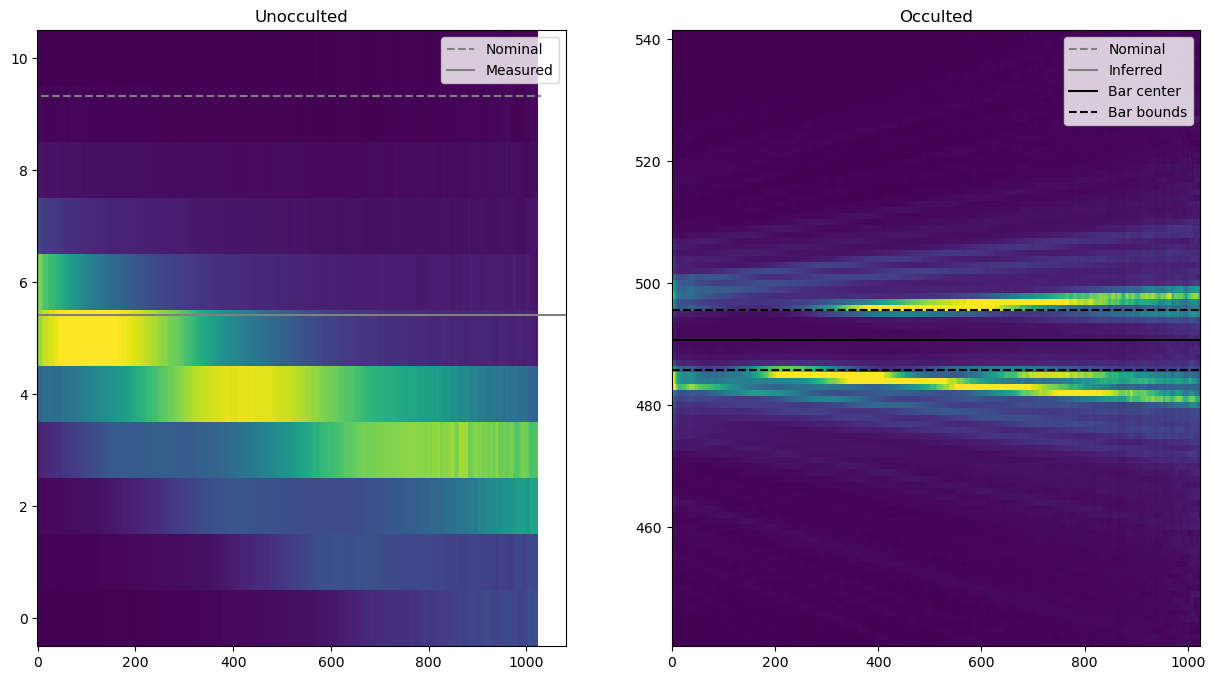

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))
# fig.suptitle(hdr['TARGNAME'] + '\n' + hdr['ROOTNAME'] + '\n' + f"POSTARG2: {hdr['POSTARG2']}")
ax = axes[0]
ax.set_title("Unocculted")
ax.imshow(
    obs.unocc_trace.data, 
    **ctmisc.img_vrange(obs.unocc_trace.data),
    origin='lower',
    interpolation='none',
)
nominal_col, nominal_row = obs.unocc_wcs.world_to_pixel_values(
    obs.wlsol, 
    units.Quantity(0, unit='deg')
)

ax.plot(
    nominal_col,
    nominal_row - obs.unocc_trace.origin_original[1],
    c='gray', ls='--', label='Nominal'
)
ax.axhline(
    obs.unocc_row - obs.unocc_trace.origin_original[1],
    c='gray', ls='-', label='Measured'
)
ax.legend()
ax.set_aspect("auto")

ax = axes[1]
ax.set_title("Occulted")
xcoords = np.arange(-0.5, obs.wlsol.size+0.5)
ycoords = np.arange(*(obs.occ_stamp.bbox_original[0] + np.array([-0.5, 1.5])))
ax.pcolormesh(
    xcoords, ycoords,
    obs.occ_stamp.data, **ctmisc.img_vrange(obs.occ_stamp.data),
)
nominal_col, nominal_row = obs.occ_wcs.world_to_pixel_values(
    obs.wlsol.min(), 
    units.Quantity(0, unit='deg')
)
ax.axhline(nominal_row , c='gray', ls='--', label='Nominal')
ax.axhline(obs.occ_row, c='gray', ls='-', label='Inferred')
ax.axhline(obs.occ_bar, ls='-', c='k', label='Bar center')
bar_lb, bar_ub = obs.get_bar_bounds()
ax.axhline(bar_lb, ls='--', c='k', label='Bar bounds')
ax.axhline(bar_ub, ls='--', c='k')
ax.legend()
ax.set_aspect("auto")

## PSF Modeling and Subtraction

The module `sdi_tools.py` contains tools for managing PSF modeling and subtraction with spectral differential imaging. Our strategy is the following:

1. Scale by wavelength
   - In the original 2-d spectral images:
     - The speckles follow the 1/lambda spread of the on-axis PSF.
     - An off-axis source is dispersed straight down the row.
   - Choose a reference wavelength, `lambda_0`, and stretch each column by the factor `lambda_0/lambda_i`
     - The speckles will now be aligned with the rows
     - An off-axis PSF will follow a `1/lambda` path.
3. Interpolate under the PSF
   - Choose a row `r` for analysis in the original image, that has a real or hypothetical PSF from an off-axis companion
   - Make a copy of the image to serve as the PSF model
   - For a given width of the PSF in rows, compute the region where the upper and lower limits of the scaled PSF cross a row
   - Mask off this region, and interpolate the values of PSF
   - In the PSF model image, replace the data in the masked region with the interpolated values
5. Subtract the model from the data
6. Project the signal along the track of the scaled companion PSF back onto the original row.
   - For each column `c`, compute the nominal row coordinate of the PSF
   - Compute the distance-weighted mean of the nearest two pixels to the nominal position*
     - This choice of algorithm is semi-arbitrary
   - This is the value for the "descaled" residual for the coordinate `(x, y) = (c, r)`

First, let's examine all the rows in the stamp

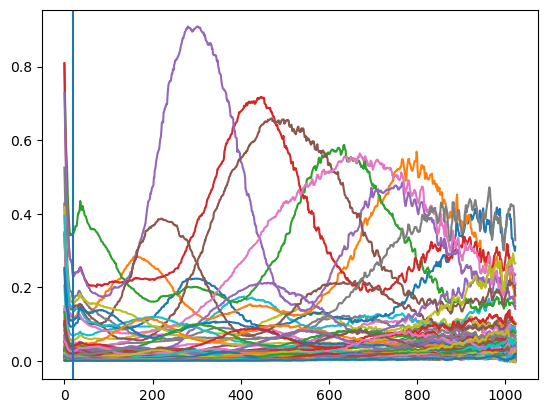

In [14]:
fig, ax = plt.subplots()
ax.plot(obs.occ_stamp.data.T);
ax.axvline(20)

I don't like how the signal spikes in the beginning and end columns so we're going to blot that out by replacing it with a constant value

In [15]:
obs.occ_stamp.data[:, :20] = obs.occ_stamp.data[:, 20, None]
obs.occ_stamp.data[:, -20:] = obs.occ_stamp.data[:, -21, None]

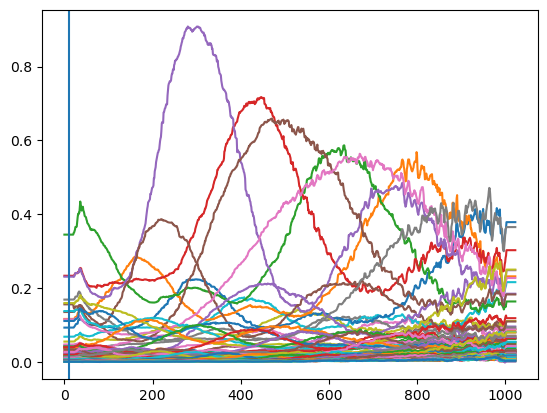

In [16]:
fig, ax = plt.subplots()
ax.plot(obs.occ_stamp.data.T);
ax.axvline(10)

## SDI class

In [17]:
from coronspec_tools import sdi_tools

In [18]:
sdi = sdi_tools.SDI(
    obs,
    ref_wl_ind=-1,#int(obs.wlsol.size/2), # scaling by longer wavelengths leaves more useable pixels at small IWAs
    psf_halfwidth=4
)
sdi_blank = sdi_tools.SDI(
    obs_blank,
    ref_wl_ind=-1,#int(obs.wlsol.size/2), # scaling by longer wavelengths leaves more useable pixels at small IWAs
    psf_halfwidth=5
)

In [19]:
# Compute the scaled stamp according to the chosen reference wavelength
sdi.compute_scaled_stamp(sdi.ref_wl_ind, obs.occ_stamp.data, obs.occ_stamp_center)

In [20]:
sdi.generate_model_results_df(20, 80)

/Users/jaguilar/Projects/miniconda3/envs/stiscoron/lib/python3.13/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/jaguilar/Projects/Research/hst17092-stis_coron/coronspec_tools/src/coronspec_tools/sdi_tools.py:125: RuntimeWarning: invalid value encountered in scalar divide
  signal[c] = np.sum(scaled_img[[r_lo,r_hi], c]*weights) / np.sum(weights)
/Users/jaguilar/Projects/Research/hst17092-stis_coron/coronspec_tools/src/coronspec_tools/sdi_tools.py:125: RuntimeWarning: invalid value encountered in multiply
  signal[c] = np.sum(scaled_img[[r_lo,r_hi], c]*weights) / np.sum(weights)


## Retriever class

In [21]:
from coronspec_tools import retrieval_tools

In [22]:
ret = retrieval_tools.Retriever(sdi)
ret_blank = retrieval_tools.Retriever(sdi_blank)

In [23]:
ret.obs.hdrs['occ'][0]['TARGNAME']

'HD-115692'

In [24]:
ret.template_trace = ret.straighten_unocc_trace(zero_max=True).copy()
ret_blank.template_trace = ret_blank.straighten_unocc_trace(zero_max=True).copy()

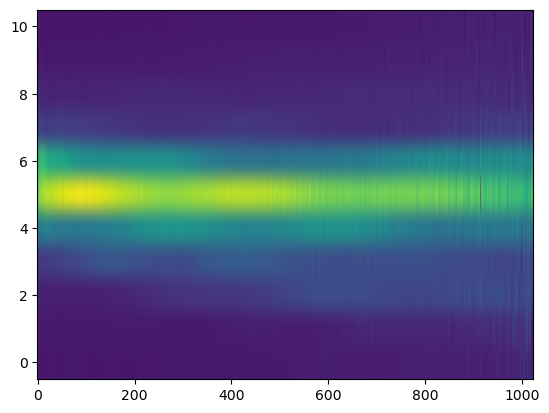

In [25]:
plt.imshow(
    ret.template_trace,# ret.obs.unocc_trace.data, 
    aspect='auto', origin='lower'
)

In [79]:
row_ind = 57
template_array = ret.obs.occ_stamp.data.copy()
ret.inject_and_process(
    template_array, 
    inj_row = row_ind,
    template_trace = ret.template_trace,
    spectrum = ret.obs.primary_spectrum.value,#/ret.obs.primary_spectrum.value.sum(), 
    scale = 0.1
)

/Users/jaguilar/Projects/miniconda3/envs/stiscoron/lib/python3.13/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/jaguilar/Projects/Research/hst17092-stis_coron/coronspec_tools/src/coronspec_tools/sdi_tools.py:125: RuntimeWarning: invalid value encountered in scalar divide
  signal[c] = np.sum(scaled_img[[r_lo,r_hi], c]*weights) / np.sum(weights)
/Users/jaguilar/Projects/miniconda3/envs/stiscoron/lib/python3.13/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/jaguilar/Projects/Research/hst17092-stis_coron/coronspec_tools/src/coronspec_tools/sdi_tools.py:125: RuntimeWarning: invalid value encountered in scalar divide
  signal[c] = np.sum(scaled_img[[r_lo,r_hi], c]*weights) / np.sum(weights)


In [80]:
ret.inj_results.loc[row_ind]

trace                [63.94571519788698, 63.93248184307961, 63.9192...
row_indices                           [57, 58, 59, 60, 61, 62, 63, 64]
scaled_stamp         [[0.024574531, 0.023700882, 0.022909937, 0.022...
scaled_stamp_unc     [[6.2717104, 6.4850907, 6.7025375, 6.712466, 6...
stamp_mask           [[True, True, True, True, True, True, True, Tr...
model                [[0.024574531242251396, 0.023700881749391556, ...
residual             [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
model_descaled       [0.111184896635039, 0.11134606411667784, 0.111...
signal               [0.13120400727241258, 0.12989491060186453, 0.1...
fm_injection         [-0.03887240748308435, -0.04055692067357024, -...
fm_ccorr                                                      8.535831
fm_ccorr_nosignal                                           -18.661762
Name: 57, dtype: object

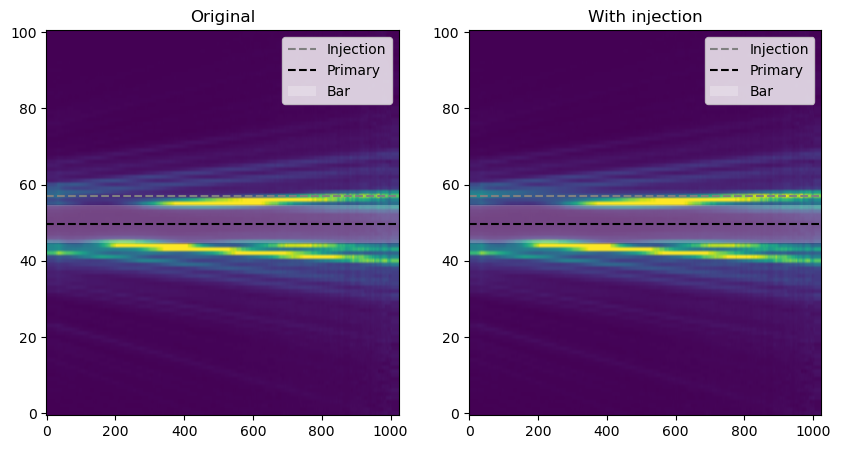

In [81]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
ax = axes[0]
ax.set_title("Original")
ax.imshow(ret.obs.occ_stamp.data, aspect='auto', origin='lower', **ctmisc.img_vrange(ret.obs.occ_stamp.data))

ax = axes[1]
ax.set_title("With injection")
ax.imshow(ret.inj_img, aspect='auto', origin='lower', **ctmisc.img_vrange(ret.inj_img))

for ax in axes.flat:
    ax.axhline(row_ind, ls='--', c='gray', label='Injection')
    
    ax.axhline(ret.obs.occ_stamp_center, c='k', ls='--', label='Primary')
    # ax.axhline(obs.occ_bar - obs.occ_stamp.origin_original[1], c='k', label='Bar')
    bar_bounds = np.array(ret.obs.get_bar_bounds()) - ret.obs.occ_stamp.origin_original[1]
    bar = mpl.patches.Rectangle((0, bar_bounds[0]), ret.inj_img.shape[1], bar_bounds[1]-bar_bounds[0], fc='w', alpha=0.25, label='Bar')
    ax.add_patch(bar)
    
    ax.legend()

In [82]:
from coronspec_tools import diagnostic_plots

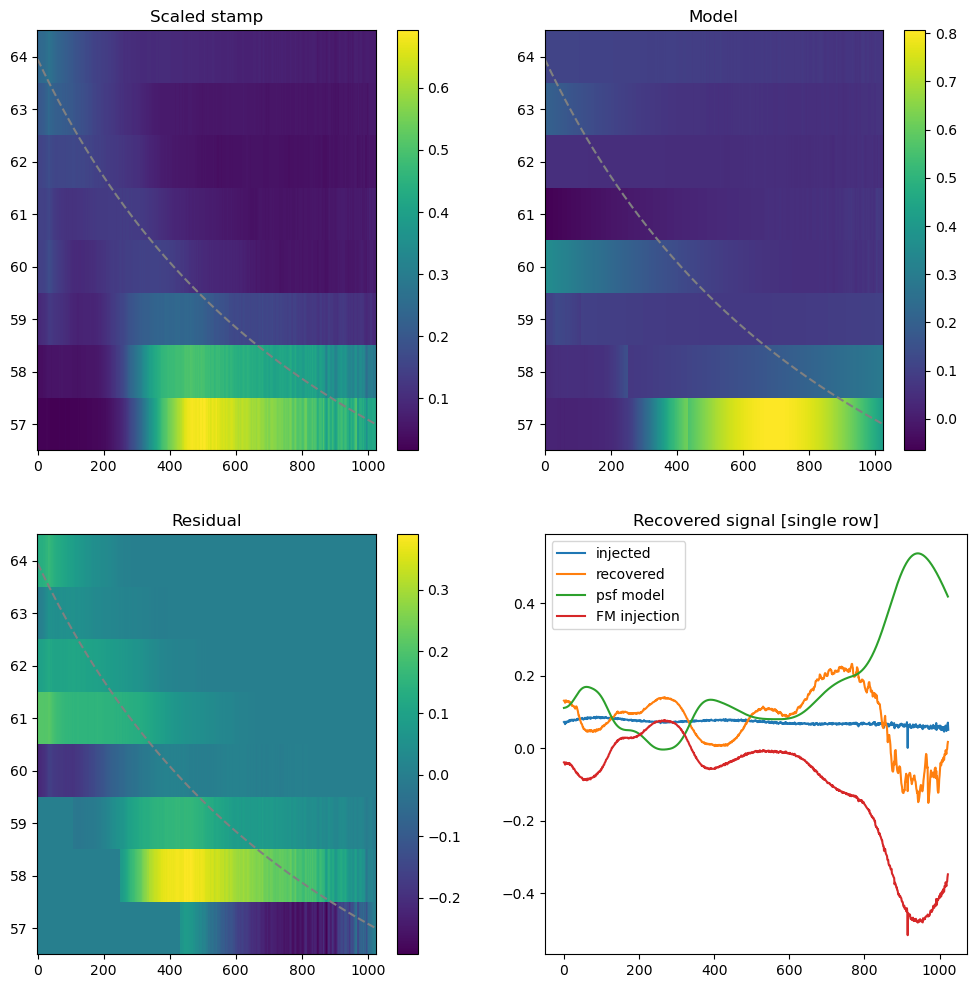

In [83]:
fig = diagnostic_plots.plot_injection_results(ret, ret.inj_results.loc[row_ind])

In [84]:
ret.inj_results

,trace,row_indices,scaled_stamp,scaled_stamp_unc,stamp_mask,model,residual,model_descaled,signal,fm_injection,fm_ccorr,fm_ccorr_nosignal
57,"[63.94571519788698, 63.93248184307961, 63.9192...","[57, 58, 59, 60, 61, 62, 63, 64]","[[0.024574531, 0.023700882, 0.022909937, 0.022...","[[6.2717104, 6.4850907, 6.7025375, 6.712466, 6...","[[True, True, True, True, True, True, True, Tr...","[[0.024574531242251396, 0.023700881749391556, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.111184896635039, 0.11134606411667784, 0.111...","[0.13120400727241258, 0.12989491060186453, 0.1...","[-0.03887240748308435, -0.04055692067357024, -...",8.535831,-18.661762


This 

In [ ]:
response = obs.primary_spectrum_flux/obs.primary_spectrum

In [ ]:
fig, ax = plt.subplots()
ax.plot(ret.obs.wlsol, ret.inj_results.loc[row_ind, 'signal'] * response)